In [27]:
# Beauty Industry Consumer Insights Analysis
# By: Maliyah Calliste Timothy
# Objective:
# Analyze beauty product data to identify factors
# influencing customer satisfaction and product performance.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("most_used_beauty_cosmetics_products_extended.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product_Name       15000 non-null  object 
 1   Brand              15000 non-null  object 
 2   Category           15000 non-null  object 
 3   Usage_Frequency    15000 non-null  object 
 4   Price_USD          15000 non-null  float64
 5   Rating             15000 non-null  float64
 6   Number_of_Reviews  15000 non-null  int64  
 7   Product_Size       15000 non-null  object 
 8   Skin_Type          15000 non-null  object 
 9   Gender_Target      15000 non-null  object 
 10  Packaging_Type     15000 non-null  object 
 11  Main_Ingredient    15000 non-null  object 
 12  Cruelty_Free       15000 non-null  bool   
 13  Country_of_Origin  15000 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(10)
memory usage: 1.5+ MB


,Price_USD,Rating,Number_of_Reviews
count,15000.000000,15000.000000,15000.000000
mean,80.134108,3.002327,5014.231333
std,40.402983,1.168029,2855.665464
min,10.000000,1.000000,52.000000
25%,45.480000,2.000000,2562.000000
50%,80.040000,3.000000,5002.000000
75%,114.760000,4.000000,7497.000000
max,149.990000,5.000000,10000.000000


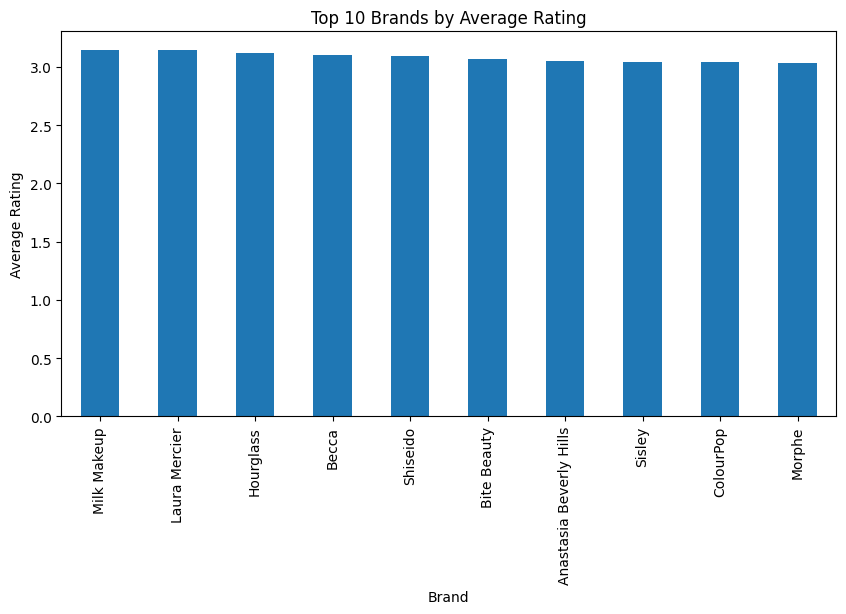

In [31]:
# ==================================================
# Analysis 1: Top-Rated Beauty Brands
# Business Question:
# Which beauty brands consistently satisfy customers?
# ==================================================

brand_ratings = (
    df.groupby("Brand")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

brand_ratings.head(10)

top_brands = brand_ratings.head(10)

plt.figure(figsize=(10,5))
top_brands.plot(kind="bar")
plt.title("Top 10 Brands by Average Rating")
plt.ylabel("Average Rating")
plt.xlabel("Brand")
plt.show()

In [30]:
# ==================================================
# Analysis 1: Top-Rated Beauty Brands
#
# Business Question:
# Which beauty brands consistently satisfy customers?
#
# Key Finding:
# Several beauty brands achieved higher average
# customer ratings than competitors, indicating
# stronger overall customer satisfaction.
#
# Business Insight:
# Understanding what drives customer satisfaction
# among top-performing brands can help guide future
# product development, branding, and marketing
# strategies.
# ==================================================

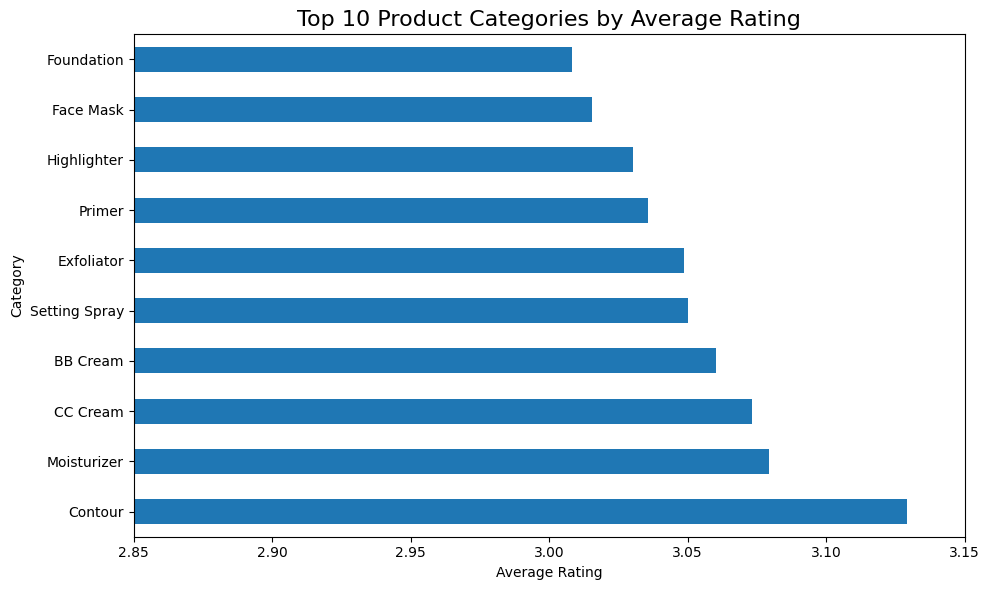

In [32]:
# ==================================================
# Analysis 2: Product Categories
# Business Question:
# Which beauty product categories receive the highest ratings?
# ==================================================

top_categories = category_ratings.head(10)

plt.figure(figsize=(10,6))

top_categories.plot(
    kind="barh"
)
plt.xlim(2.85, 3.15)

plt.title("Top 10 Product Categories by Average Rating", fontsize=16)
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.tight_layout()
plt.show()



In [ ]:
# ==================================================
# Analysis 2: Product Categories
#
# Business Question:
# Which beauty product categories receive the
# strongest customer ratings?
#
# Key Finding:
# Average ratings remained relatively consistent
# across product categories, with only minor
# differences between the highest and lowest
# rated categories.
#
# Business Insight:
# Customer satisfaction appears to be influenced
# more by individual product quality and brand
# performance than category alone.
# ==================================================

Average Rating (Most Expensive): 2.95
Average Rating (Least Expensive): 2.79


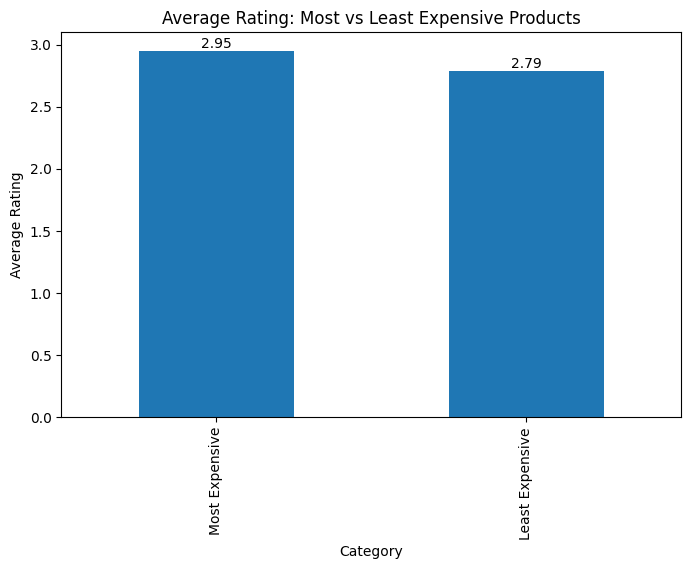

In [33]:
# ==================================================
# Analysis 3: Price vs Rating
# Business Question:
# Do more expensive beauty products receive better ratings?
# ==================================================

top_expensive = df.nlargest(100, "Price_USD")[
    ["Product_Name", "Brand", "Category", "Price_USD", "Rating"]
]

top_expensive

least_expensive = df.nsmallest(100, "Price_USD")[
    ["Product_Name", "Brand", "Category", "Price_USD", "Rating"]
]

least_expensive

highest_avg_rating = top_expensive["Rating"].mean()
lowest_avg_rating = least_expensive["Rating"].mean()

print(f"Average Rating (Most Expensive): {highest_avg_rating:.2f}")
print(f"Average Rating (Least Expensive): {lowest_avg_rating:.2f}")


comparison = pd.DataFrame({
    "Category": ["Most Expensive", "Least Expensive"],
    "Average Rating": [highest_avg_rating, lowest_avg_rating]
})

ax = comparison.plot(
    x="Category",
    y="Average Rating",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Average Rating: Most vs Least Expensive Products")
plt.ylabel("Average Rating")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

In [ ]:
# ==================================================
# Analysis 3: Pricing and Customer Satisfaction
#
# Business Question:
# Do higher-priced beauty products earn better
# customer ratings?
#
# Key Finding:
# Premium-priced products received slightly higher
# average ratings than lower-priced products,
# although the difference was modest.
#
# Business Insight:
# Premium pricing alone does not guarantee higher
# customer satisfaction. Product effectiveness,
# ingredients, and customer experience appear to
# have a greater influence on ratings.
# ==================================================

Cruelty_Free
False    2.999065
True     3.005670
Name: Rating, dtype: float64


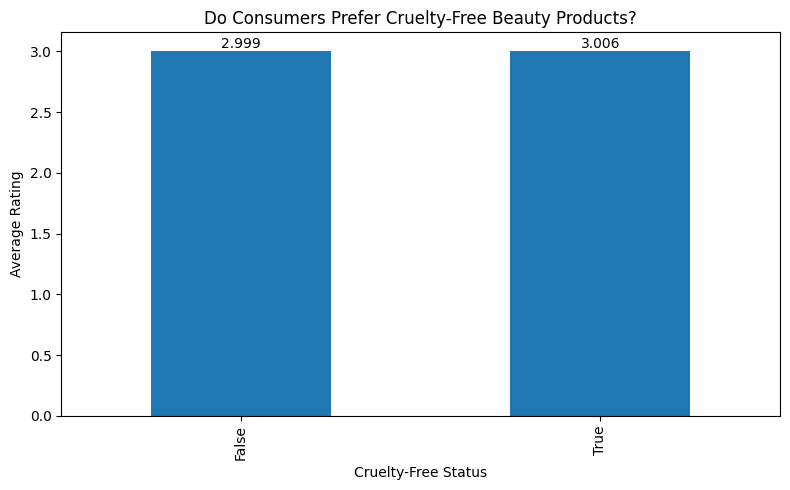

In [34]:
# ==================================================
# Analysis 4: Cruelty-Free Products
# Business Question:
# Does cruelty-free status influence customer satisfaction?
# ==================================================

cruelty_ratings = (
    df.groupby("Cruelty_Free")["Rating"]
    .mean()
)

print(cruelty_ratings)

# Visualize results
ax = cruelty_ratings.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Do Consumers Prefer Cruelty-Free Beauty Products?")
plt.xlabel("Cruelty-Free Status")
plt.ylabel("Average Rating")

# Add values above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.show()

In [ ]:
# ==================================================
# Analysis 4: Cruelty-Free Products
#
# Business Question:
# Do consumers prefer cruelty-free beauty products?
#
# Key Finding:
# Cruelty-free products received slightly higher
# average ratings than non-cruelty-free products,
# although the difference was minimal.
#
# Business Insight:
# Ethical product positioning may positively
# influence consumer perception, but cruelty-free
# status alone is unlikely to be a major driver
# of customer satisfaction.
# ==================================================

Number of highly-rated products: 4070
Main_Ingredient
Shea Butter        628
Glycerin           589
Hyaluronic Acid    578
Retinol            578
Vitamin C          577
Aloe Vera          564
Salicylic Acid     556
Name: count, dtype: int64


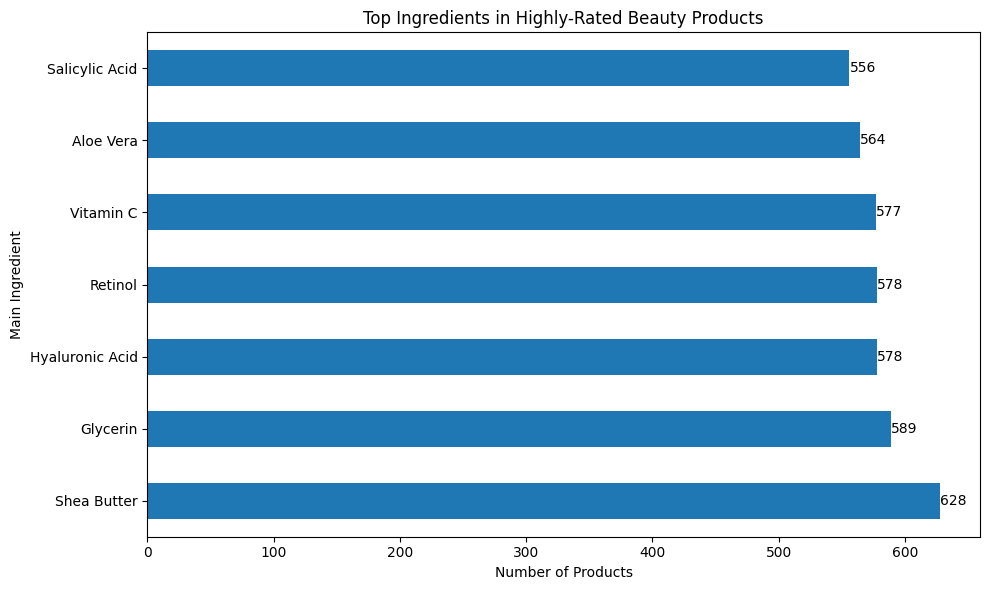

In [35]:
# ==================================================
# Analysis 5: Ingredients
# Business Question:
# Which ingredients appear most frequently in highly-rated products?
# ==================================================

# Filter products with ratings of 4.0 or higher
high_rated = df[df["Rating"] >= 4.0]

print(f"Number of highly-rated products: {len(high_rated)}")

top_ingredients = (
    high_rated["Main_Ingredient"]
    .value_counts()
    .head(10)
)

print(top_ingredients)

plt.figure(figsize=(10,6))

ax = top_ingredients.plot(
    kind="barh"
)

plt.title("Top Ingredients in Highly-Rated Beauty Products")
plt.xlabel("Number of Products")
plt.ylabel("Main Ingredient")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [ ]:
# ==================================================
# Analysis 5: Ingredients Associated with
# High Customer Satisfaction
#
# Business Question:
# Which ingredients appear most frequently in
# highly-rated beauty products?
#
# Key Finding:
# Ingredients such as Hyaluronic Acid, Retinol,
# Vitamin C, Shea Butter, Aloe Vera, and Glycerin
# appeared frequently among highly-rated products.
#
# Business Insight:
# Consumers appear to value ingredients associated
# with hydration, repair, and targeted skincare
# benefits, creating opportunities for future
# product development and positioning.
# ==================================================

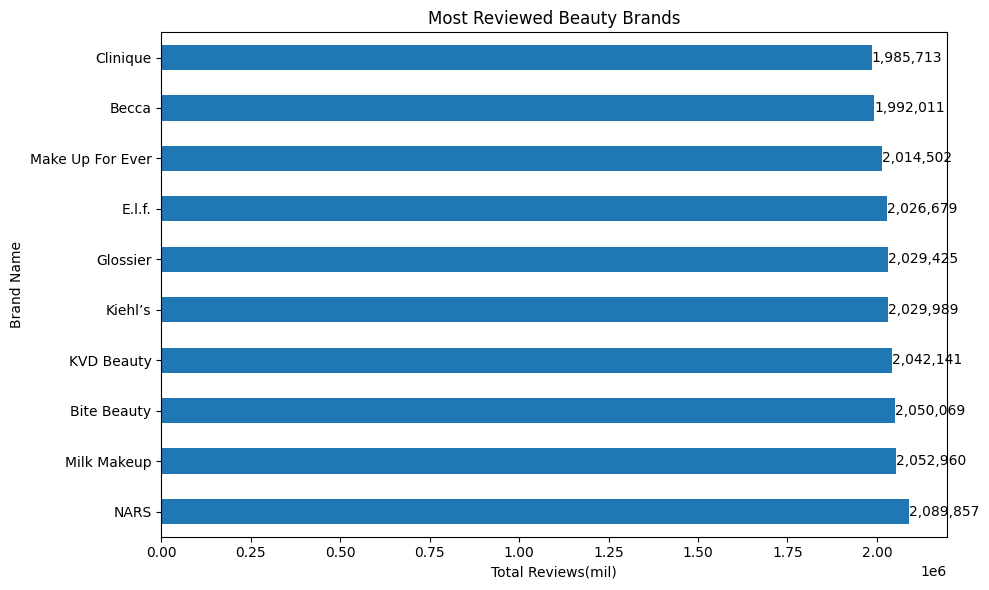

In [41]:
top_reviewed_brands = (
    df.groupby("Brand")["Number_of_Reviews"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

ax = top_reviewed_brands.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Most Reviewed Beauty Brands")
plt.xlabel("Total Reviews(mil)")
plt.ylabel("Brand Name")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}'
    )

plt.tight_layout()
plt.show()

In [ ]:
# ==================================================
# Analysis 6: Consumer Engagement by Brand
#
# Business Question:
# Which beauty brands generate the highest levels
# of consumer engagement?
#
# Key Finding:
# Brands such as NARS, Milk Makeup, Bite Beauty,
# KVD Beauty, and Kiehl's generated the highest
# review volumes among analyzed brands.
#
# Business Insight:
# High review volume may indicate strong consumer
# engagement, brand awareness, and opportunities
# to collect customer feedback for continuous
# product improvement.
# ==================================================

In [36]:
# ==================================================
# Executive Summary
#
# Key Findings:
# - Customer ratings were relatively consistent
#   across beauty product categories.
# - Premium-priced products achieved slightly
#   higher ratings than lower-priced alternatives.
# - Cruelty-free products received marginally
#   higher ratings than non-cruelty-free products.
# - Hydration and treatment-focused ingredients
#   appeared frequently among highly-rated products.
# - Several brands demonstrated exceptionally
#   strong consumer engagement through high
#   review volumes.
#
# Strategic Recommendations:
# 1. Prioritize ingredient effectiveness over
#    premium pricing strategies.
# 2. Continue incorporating high-performing
#    skincare ingredients into product development.
# 3. Maintain cruelty-free positioning as a
#    supporting brand value.
# 4. Monitor highly engaged brands to identify
#    successful marketing and engagement practices.
# 5. Combine ratings, reviews, and ingredient
#    analysis when evaluating future products.
# ==================================================